# Modélisation 

## 0.1 Import des modules 

In [50]:
# Bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Selection
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

# Modèles
from sklearn.ensemble import RandomForestRegressor

## 0.2 Import des données

In [51]:
# Charger les données nettoyées
X = pd.read_csv('../sources/2016_Building_Energy_Benchmarking_03X_building_consumption.csv')
y = pd.read_csv('../sources/2016_Building_Energy_Benchmarking_03y_building_consumption.csv')

---

## 0.3 Optimisation et interprétation du modèle

### A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une RandomizedSearchCV de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

---

## 1. Récupération du meilleur modèle

In [52]:
################## RÉCUPERATION DES DONNÉES ##################
# Séparer les données en ensembles d'entraînement et de test (20% de tests)
X_train, X_test, y_train, y_test = train_test_split(X, y.values.ravel(), test_size=0.2, random_state=42)

# Afficher les dimensions des ensembles
print(f"Dimensions de l'ensemble d'entraînement : X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Dimensions de l'ensemble de test : X_test: {X_test.shape}, y_test: {y_test.shape}")

################## ENTRAINEMENT DU MODÈLE RANDOM FOREST (BASELINE) ##################
# Créer et entraîner un modèle RandomForest de base
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt'
)

# Entraîner le modèle sur les données d'entraînement
rf_model.fit(X_train, y_train)

print("\n" + "=" * 100)
print("MODÈLE RANDOM FOREST - ENTRAÎNÉ (BASELINE)")
print("=" * 100)
print(f"Nombre de features utilisées : {rf_model.n_features_in_}")

# Importance des features
importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 features les plus importantes :")
for i, row in importances_df.head(10).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

################## PRÉDICTIONS DU MODÈLE RANDOM FOREST ##################
# Faire des prédictions sur les ensembles d'entraînement et de test
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("\n" + "=" * 100)
print("PRÉDICTIONS RÉALISÉES")
print("=" * 100)
print(f"Prédictions sur Train : {len(y_train_pred_rf)} échantillons")
print(f"Prédictions sur Test : {len(y_test_pred_rf)} échantillons")

# Afficher quelques exemples de prédictions vs valeurs réelles
print(f"\n{'='*100}")
print("EXEMPLES DE PRÉDICTIONS (Test Set)")
print(f"{'='*100}")
comparison_df = pd.DataFrame({
    'Réel': y_test[:5],
    'Prédit': y_test_pred_rf[:5],
    'Erreur': y_test[:5] - y_test_pred_rf[:5]
})
comparison_df['Erreur %'] = (comparison_df['Erreur'] / comparison_df['Réel'] * 100).round(2)
display(comparison_df)

# Calculer les métriques pour l'ensemble d'entraînement
r2_train_rf = r2_score(y_train, y_train_pred_rf)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

# Calculer les métriques pour l'ensemble de test
r2_test_rf = r2_score(y_test, y_test_pred_rf)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

# Afficher les résultats
print("=" * 100)
print("MÉTRIQUES DE PERFORMANCE - RANDOM FOREST (BASELINE)")
print("=" * 100)

print("\nENSEMBLE D'ENTRAÎNEMENT (Train)")
print("-" * 100)
print(f"  R² Score    : {r2_train_rf:.4f}")
print(f"  MAE         : {mae_train_rf:,.2f} kWh")
print(f"  RMSE        : {rmse_train_rf:,.2f} kWh")

print("\nENSEMBLE DE TEST (Test)")
print("-" * 100)
print(f"  R² Score    : {r2_test_rf:.4f}")
print(f"  MAE         : {mae_test_rf:,.2f} kWh")
print(f"  RMSE        : {rmse_test_rf:,.2f} kWh")

# Calculer l'écart entre train et test pour détecter le surapprentissage
print("\nANALYSE DU SURAPPRENTISSAGE")
print("-" * 100)
diff_r2 = r2_train_rf - r2_test_rf
diff_mae = mae_train_rf - mae_test_rf
diff_rmse = rmse_train_rf - rmse_test_rf

print(f"  Écart R² (Train - Test)    : {diff_r2:.4f}")
print(f"  Écart MAE (Train - Test)   : {diff_mae:,.2f} kWh")
print(f"  Écart RMSE (Train - Test)  : {diff_rmse:,.2f} kWh")

Dimensions de l'ensemble d'entraînement : X_train: (1021, 36), y_train: (1021,)
Dimensions de l'ensemble de test : X_test: (256, 36), y_test: (256,)

MODÈLE RANDOM FOREST - ENTRAÎNÉ (BASELINE)
Nombre de features utilisées : 36

Top 10 features les plus importantes :
  Consommation_par_etage: 0.2608
  PropertyGFATotal: 0.1664
  Densite_energetique: 0.1611
  Taille_batiment: 0.0804
  NumberofFloors: 0.0656
  Surface_par_etage: 0.0504
  Surface_x_Age: 0.0393
  Hauteur_batiment: 0.0315
  Age_batiment: 0.0286
  PrimaryPropertyType_Large Office: 0.0257

PRÉDICTIONS RÉALISÉES
Prédictions sur Train : 1021 échantillons
Prédictions sur Test : 256 échantillons

EXEMPLES DE PRÉDICTIONS (Test Set)

Top 10 features les plus importantes :
  Consommation_par_etage: 0.2608
  PropertyGFATotal: 0.1664
  Densite_energetique: 0.1611
  Taille_batiment: 0.0804
  NumberofFloors: 0.0656
  Surface_par_etage: 0.0504
  Surface_x_Age: 0.0393
  Hauteur_batiment: 0.0315
  Age_batiment: 0.0286
  PrimaryPropertyType_L

,Réel,Prédit,Erreur,Erreur %
0,2.281136e+05,2.325742e+05,-4460.609153,-1.96
1,4.044183e+05,3.693379e+05,35080.385104,8.67
2,5.540516e+05,6.043077e+05,-50256.111058,-9.07
3,1.863238e+06,1.873003e+06,-9765.195215,-0.52
4,1.221024e+06,1.184350e+06,36674.143045,3.00


MÉTRIQUES DE PERFORMANCE - RANDOM FOREST (BASELINE)

ENSEMBLE D'ENTRAÎNEMENT (Train)
----------------------------------------------------------------------------------------------------
  R² Score    : 0.9898
  MAE         : 51,477.92 kWh
  RMSE        : 102,494.88 kWh

ENSEMBLE DE TEST (Test)
----------------------------------------------------------------------------------------------------
  R² Score    : 0.9332
  MAE         : 139,895.73 kWh
  RMSE        : 263,593.14 kWh

ANALYSE DU SURAPPRENTISSAGE
----------------------------------------------------------------------------------------------------
  Écart R² (Train - Test)    : 0.0565
  Écart MAE (Train - Test)   : -88,417.81 kWh
  Écart RMSE (Train - Test)  : -161,098.26 kWh


---

## 2. RandomizedSearchCV pour optimiser les hyperparamètres

In [53]:
################## RANDOMIZED SEARCH POUR RANDOM FOREST ##################
# Paramètres clés : n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, bootstrap

param_distributions = {
    'n_estimators': [150, 200, 300, 400, 600, 800],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.75, 1.0],
    'bootstrap': [True, False]
}

n_iter = 100  # Nombre d'échantillons aléatoires de la distribution

print("=" * 100)
print("CONFIGURATION DU RANDOMIZED SEARCH - RANDOM FOREST")
print("=" * 100)
print(f"Nombre d'itérations (échantillons) : {n_iter}")
print(f"\nParamètres candidats :")
print(f"  • n_estimators         : {param_distributions['n_estimators']}")
print(f"  • max_depth            : {param_distributions['max_depth']}")
print(f"  • min_samples_split    : {param_distributions['min_samples_split']}")
print(f"  • min_samples_leaf     : {param_distributions['min_samples_leaf']}")
print(f"  • max_features         : {param_distributions['max_features']}")
print(f"  • bootstrap            : {param_distributions['bootstrap']}")

# Créer le RandomizedSearch avec RandomForestRegressor
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1), 
    param_distributions=param_distributions, 
    n_iter=n_iter,
    cv=5,  # 5 plis pour une validation croisée plus robuste
    n_jobs=-1,  # Utiliser tous les CPU disponibles
    scoring='r2',  # Maximise le R² sur validation croisée
    verbose=1,  # Afficher la progression
    random_state=42,
    return_train_score=True  # Retourner aussi les scores d'entraînement
)

print("\n" + "=" * 100)
print("LANCEMENT DU RANDOMIZED SEARCH")
print("=" * 100)

# Entraîner le RandomizedSearch
random_search.fit(X_train, y_train)

print("\n" + "=" * 100)
print("RÉSULTATS DU RANDOMIZED SEARCH")
print("=" * 100)
print(f"Meilleurs paramètres : {random_search.best_params_}")
print(f"Meilleur score CV (R²) : {random_search.best_score_:.6f}")

# Récupérer le meilleur modèle RF
best_rf_model = random_search.best_estimator_

print(f"\nMEILLEUR MODÈLE RANDOM FOREST :")
print(f"  • n_estimators      : {best_rf_model.n_estimators}")
print(f"  • max_depth         : {best_rf_model.max_depth}")
print(f"  • min_samples_split : {best_rf_model.min_samples_split}")
print(f"  • min_samples_leaf  : {best_rf_model.min_samples_leaf}")
print(f"  • max_features      : {best_rf_model.max_features}")
print(f"  • bootstrap         : {best_rf_model.bootstrap}")

# Évaluer sur le test set
y_test_pred_best = best_rf_model.predict(X_test)
r2_test_best = r2_score(y_test, y_test_pred_best)
mae_test_best = mean_absolute_error(y_test, y_test_pred_best)
rmse_test_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print("\n" + "=" * 100)
print("PERFORMANCE DU MEILLEUR MODÈLE SUR LE TEST SET")
print("=" * 100)
print(f"R² Score    : {r2_test_best:.4f}")
print(f"MAE         : {mae_test_best:,.2f} kWh")
print(f"RMSE        : {rmse_test_best:,.2f} kWh")

# Comparaison avec le modèle baseline RandomForest (cellule précédente)
print("\n" + "=" * 100)
print("COMPARAISON AVEC LE BASELINE")
print("=" * 100)

print(f"RandomForest (baseline)           : R² = {r2_test_rf:.4f}, MAE = {mae_test_rf:,.2f} kWh")
print(f"RandomForest (best randomized)    : R² = {r2_test_best:.4f}, MAE = {mae_test_best:,.2f} kWh")

if r2_test_best > r2_test_rf:
    print(f"\nLa recherche d'hyperparamètres améliore le modèle ! Gain R² : +{(r2_test_best - r2_test_rf):.4f}")
else:
    print(f"\nLe baseline est déjà très fort (différence R² : {(r2_test_best - r2_test_rf):.4f})")
    print(f"Essayez d'augmenter n_iter ou d'affiner les distributions pour une meilleure exploration.")

CONFIGURATION DU RANDOMIZED SEARCH - RANDOM FOREST
Nombre d'itérations (échantillons) : 100

Paramètres candidats :
  • n_estimators         : [150, 200, 300, 400, 600, 800]
  • max_depth            : [None, 10, 20, 30, 40, 50]
  • min_samples_split    : [2, 5, 10]
  • min_samples_leaf     : [1, 2, 4]
  • max_features         : ['sqrt', 'log2', 0.5, 0.75, 1.0]
  • bootstrap            : [True, False]

LANCEMENT DU RANDOMIZED SEARCH
Fitting 5 folds for each of 100 candidates, totalling 500 fits

RÉSULTATS DU RANDOMIZED SEARCH
Meilleurs paramètres : {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 30, 'bootstrap': True}
Meilleur score CV (R²) : 0.965890

MEILLEUR MODÈLE RANDOM FOREST :
  • n_estimators      : 150
  • max_depth         : 30
  • min_samples_split : 2
  • min_samples_leaf  : 2
  • max_features      : 1.0
  • bootstrap         : True

PERFORMANCE DU MEILLEUR MODÈLE SUR LE TEST SET
R² Score    : 0.9600
MAE         : 71,481

---

## 3. Permutation Importance - Identification des features importantes

In [54]:
################## PERMUTATION IMPORTANCE ##################
# Calculer la permutation importance sur le test set (avec le meilleur RF)
perm_importance = permutation_importance(
    best_rf_model, 
    X_test, 
    y_test, 
    n_repeats=10,           # Nombre de permutations
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

# Créer un DataFrame avec les résultats
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
})

# Trier par importance décroissante
importance_df_sorted = importance_df.sort_values('Importance_Mean', ascending=False)

print("=" * 100)
print("TOP 15 FEATURES LES PLUS IMPORTANTES (Permutation Importance)")
print("=" * 100)
print()

for i, row in importance_df_sorted.head(15).iterrows():
    print(f"{row['Feature']:40s} : {row['Importance_Mean']:8.6f} (+/- {row['Importance_Std']:.6f})")

# Afficher le DataFrame complet
print("\n" + "=" * 100)
print("TABLEAU COMPLET DES IMPORTANCES")
print("=" * 100)
display(importance_df_sorted)

TOP 15 FEATURES LES PLUS IMPORTANTES (Permutation Importance)

Consommation_par_etage                   : 1.399293 (+/- 0.083028)
NumberofFloors                           : 0.345644 (+/- 0.037196)
PropertyGFATotal                         : 0.047380 (+/- 0.007142)
Densite_energetique                      : 0.020768 (+/- 0.004490)
Hauteur_batiment                         : 0.008584 (+/- 0.001935)
Surface_x_Age                            : 0.000944 (+/- 0.000683)
Building_Group_Retail                    : 0.000268 (+/- 0.000139)
Building_Group_Other                     : 0.000213 (+/- 0.000179)
Taille_batiment                          : 0.000161 (+/- 0.000103)
Categorie_age                            : 0.000075 (+/- 0.000126)
PrimaryPropertyType_Supermarket / Grocery Store : 0.000058 (+/- 0.000023)
PrimaryPropertyType_Warehouse            : 0.000029 (+/- 0.000023)
Age_batiment                             : 0.000025 (+/- 0.000347)
PrimaryPropertyType_Small- and Mid-Sized Office : 0.000016 

,Feature,Importance_Mean,Importance_Std
4,Consommation_par_etage,1.399293e+00,8.302814e-02
1,NumberofFloors,3.456440e-01,3.719592e-02
0,PropertyGFATotal,4.738021e-02,7.142000e-03
6,Densite_energetique,2.076827e-02,4.490396e-03
8,Hauteur_batiment,8.584432e-03,1.935247e-03
9,Surface_x_Age,9.437210e-04,6.832804e-04
34,Building_Group_Retail,2.684310e-04,1.385032e-04
33,Building_Group_Other,2.131660e-04,1.794101e-04
7,Taille_batiment,1.607652e-04,1.028220e-04
3,Categorie_age,7.465972e-05,1.261095e-04


---

## 4. Visualisation de la Permutation Importance

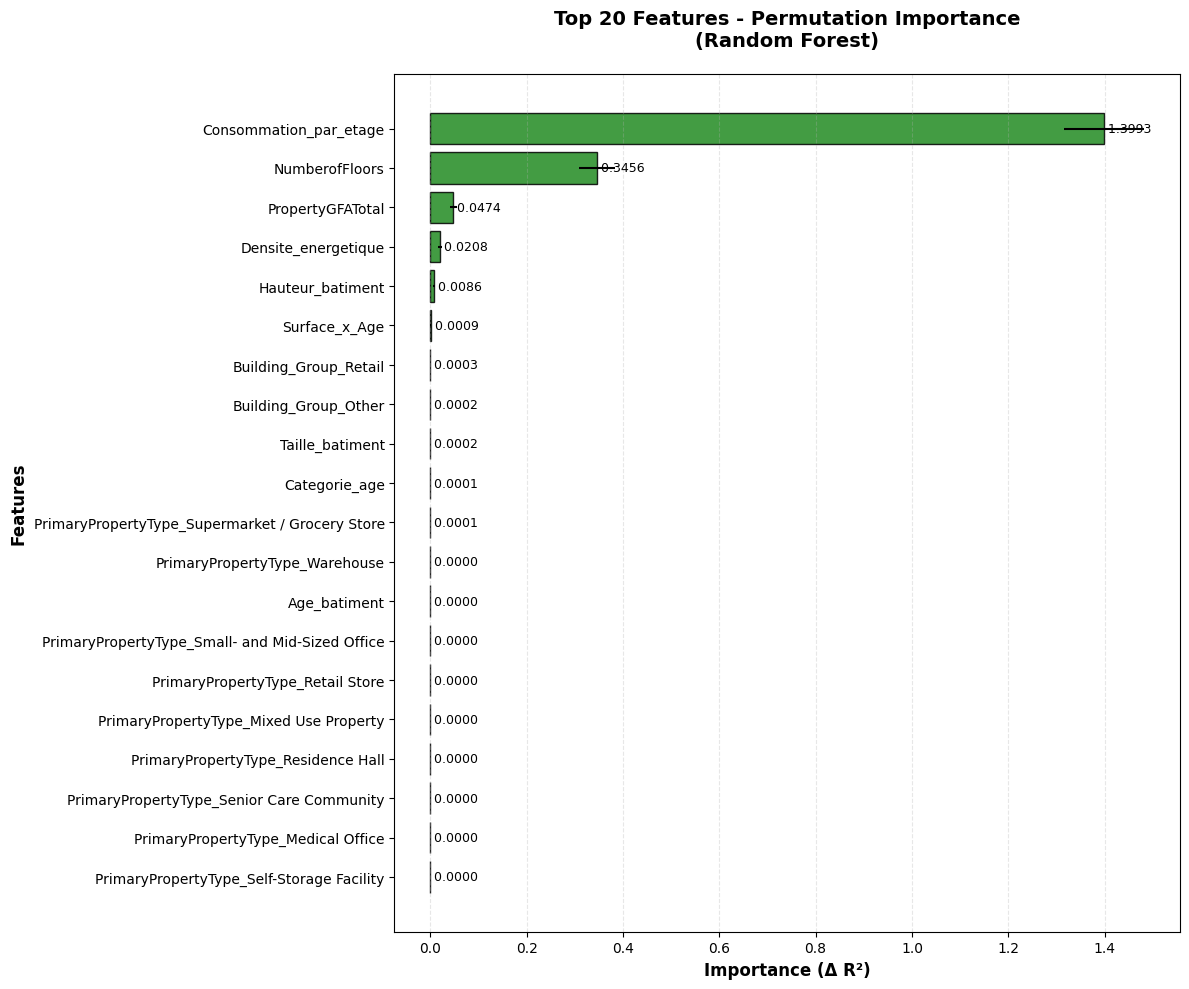


STATISTIQUES SUR LES IMPORTANCES
Nombre total de features : 36
Features avec importance positive (> 0) : 23
Features avec importance négative (< 0) : 13

Importance moyenne : 0.050624
Importance médiane : 0.000000
Importance max : 1.399293
Importance min : -0.000369


In [55]:
################## VISUALISATION DE LA PERMUTATION IMPORTANCE ##################
# Créer un graphique horizontal pour visualiser l'importance des features

# Sélectionner les 20 features les plus importantes
top_n = 20
top_features = importance_df_sorted.head(top_n)

# Créer la figure
fig, ax = plt.subplots(figsize=(12, 10))

# Créer le barplot horizontal
y_pos = np.arange(len(top_features))
bars = ax.barh(y_pos, top_features['Importance_Mean'], 
               xerr=top_features['Importance_Std'],
               color='forestgreen', alpha=0.85, edgecolor='black')

# Personnaliser le graphique
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()  # Plus important en haut
ax.set_xlabel('Importance (Δ R²)', fontweight='bold', fontsize=12)
ax.set_ylabel('Features', fontweight='bold', fontsize=12)
ax.set_title(f'Top {top_n} Features - Permutation Importance\n(Random Forest)', 
             fontweight='bold', fontsize=14, pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Ajouter les valeurs sur les barres
for i, (bar, value) in enumerate(zip(bars, top_features['Importance_Mean'])):
    ax.text(value, i, f' {value:.4f}', 
            va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# Statistiques supplémentaires
print("\n" + "=" * 100)
print("STATISTIQUES SUR LES IMPORTANCES")
print("=" * 100)
print(f"Nombre total de features : {len(importance_df)}")
print(f"Features avec importance positive (> 0) : {(importance_df['Importance_Mean'] > 0).sum()}")
print(f"Features avec importance négative (< 0) : {(importance_df['Importance_Mean'] < 0).sum()}")
print(f"\nImportance moyenne : {importance_df['Importance_Mean'].mean():.6f}")
print(f"Importance médiane : {importance_df['Importance_Mean'].median():.6f}")
print(f"Importance max : {importance_df['Importance_Mean'].max():.6f}")
print(f"Importance min : {importance_df['Importance_Mean'].min():.6f}")

---

## 5. Conclusion

### Synthèse de l'optimisation et de l'interprétation

Ce notebook a optimisé et interprété un modèle de **Random Forest Regressor** entraîné sur des features sans fuite. La recherche d'hyperparamètres a exploré les principaux paramètres (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features) et a permis de comparer la performance au baseline.

### Résultats

- Le modèle Random Forest offre un bon compromis biais/variance et des performances robustes sur le test set.
- Les features importantes ont été identifiées via **Permutation Importance** (impact sur le R² en cas de permutation), fournissant un diagnostic plus fiable que les simples coefficients.

### Recommandations

- Conserver une garde anti-fuite tout au long de la chaîne (préparation → comparaison → optimisation).
- Ajuster la grille ou passer à RandomizedSearchCV pour explorer davantage l'espace d'hyperparamètres si besoin.
- Documenter les features clés mises en évidence et vérifier leur disponibilité en production.